### Caminhos Mais Rentáveis — Aquisição de Pacientes Novos

**Pergunta:** Qual o caminho para trazer o paciente novo na Dasa? Qual o mais rentável?

A métrica principal é o `score_rentabilidade_12m` = LTV 12M × taxa de retenção 12M.  
Ela equilibra **quanto o paciente gera** com **por quanto tempo ele fica**.

In [1]:
from google.cloud import bigquery
from google.cloud import bigquery_storage
client = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Imports OK')

✅ Imports OK


In [2]:
query = (
"""
WITH

ga4_attribution AS (
  SELECT
    data AS data_evento,
    user_id,
    channel_group,
    campaign_non_direct,
    'NAV' AS tp_origem_agendamento
  FROM `prj-analytics-ga.ds_dimfacto_dataform_nav_pac_attribution.tb_dim_ga_nav_pac_attribution_nova_taxo`
  WHERE user_id IS NOT NULL
    AND data >= '2025-10-01'
    AND data < '2026-05-01'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY user_id, data
    ORDER BY ga_session_id DESC
  ) = 1
),

agd_template AS (
  SELECT
    DATE(agd.dt_criacao_agendamento) AS data_agendamento,
    agd.id_paciente,
    agd.id_agendamento,
    ga.campaign_non_direct,
    id_atendimento_final,
  FROM `dasa-business-intelligence-prd.ds_datamart_agendamento.fct_datamart_agendamento_dasa` agd
  ,UNNEST(SPLIT(COALESCE(id_atendimento_realizado_paciente, id_atendimento_realizado, id_atendimento_agenda), ';')) AS id_atendimento_final
  LEFT JOIN ga4_attribution ga
    ON ga.user_id = agd.id_paciente
    AND DATE(ga.data_evento) = DATE(agd.dt_criacao_agendamento)
  WHERE DATE(dt_criacao_agendamento) >= '2025-10-01'
    AND DATE(dt_criacao_agendamento) < '2026-05-01'
    AND st_agendamento <> 'CANCELLED'
    AND agd.tp_origem_agendamento NOT IN ('NAV_PRO', 'NAV_WEB')
  GROUP BY ALL
),

atd_template AS (
  SELECT
    DATE_TRUNC(DATE(dt_atendimento), MONTH) AS mes_atendimento,
    dt_atendimento,
    id_atendimento,
    nu_cpf_paciente,
    nm_grupo_mercado_exame AS grupo_exames,
  FROM `dasa-business-intelligence-prd.ds_datamart_atendimento.fct_datamart_atendimento`
  WHERE dt_atendimento >= '2025-10-01'
    AND dt_atendimento < '2026-05-01'
    AND nm_mercado_unidade IN ('PRIVADO','PREMIUM')
    AND handle_fato_excluido = 'NAO'
  GROUP BY ALL
),

unificacao AS (
  SELECT
    atd.*,
    agd.campaign_non_direct,
  FROM atd_template atd
  LEFT JOIN (
    SELECT * FROM agd_template
    QUALIFY ROW_NUMBER() OVER (
      PARTITION BY id_atendimento_final
      ORDER BY data_agendamento DESC
    ) = 1
  ) agd
  ON agd.id_atendimento_final = atd.id_atendimento
),

coorte_aquisicao AS (
  SELECT
    nu_cpf_paciente,
    mes_atendimento AS mes_coorte,
    COALESCE(channel_group, 'Nao Identificado') AS subcanal_aquisicao,
    COALESCE(origem_agd, 'Nao Identificado')    AS canal_aquisicao,
    COALESCE(marca, 'Nao Identificado')         AS marca,
    COALESCE(desc_operadora, 'Nao Identificado') AS desc_operadora,
    faixa_etaria,
    sexo_paciente
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE classificacao_paciente_dasa = 'novo'
    AND mes_atendimento >= '2025-10-01'
    AND mes_atendimento < '2026-05-01'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY nu_cpf_paciente
    ORDER BY mes_atendimento ASC
  ) = 1
),

receita_por_mes AS (
  SELECT
    nu_cpf_paciente,
    mes_atendimento,
    SUM(receita) AS receita_mes
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE mes_atendimento >= '2025-10-01'
    AND mes_atendimento < '2026-05-01'
    AND classificacao_paciente_dasa IN ('novo', 'recorrente', 'recuperado')
  GROUP BY ALL
),

coorte_receita AS (
  SELECT
    c.nu_cpf_paciente,
    c.mes_coorte,
    c.canal_aquisicao,
    c.subcanal_aquisicao,
    c.marca,
    c.desc_operadora,
    c.faixa_etaria,
    c.sexo_paciente,
    r.mes_atendimento,
    DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) AS mes_desde_aquisicao,
    r.receita_mes
  FROM coorte_aquisicao c
  INNER JOIN receita_por_mes r
    ON r.nu_cpf_paciente = c.nu_cpf_paciente
   AND r.mes_atendimento >= c.mes_coorte
),

-- ← CORRIGIDO: deduplicação antes do join evita multiplicação de linhas
dim_coorte AS (
  SELECT
    cr.*,
    u.campaign_non_direct,
    u.grupo_exames,      
  FROM coorte_receita cr
  LEFT JOIN (
    SELECT
      nu_cpf_paciente,
      mes_atendimento,
      -- Se o paciente teve múltiplas campanhas no mês, pega a mais frequente
      -- Troque por MAX() se preferir a mais recente
      MAX(campaign_non_direct) AS campaign_non_direct,
      MAX(grupo_exames)        AS grupo_exames
    FROM unificacao
    GROUP BY nu_cpf_paciente, mes_atendimento
  ) u
  ON cr.nu_cpf_paciente  = u.nu_cpf_paciente
 AND cr.mes_atendimento  = u.mes_atendimento
),

ltv_combinacoes AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    desc_operadora,
    grupo_exames,         
    campaign_non_direct, 
    marca,
    faixa_etaria,
    sexo_paciente,

    COUNT(DISTINCT nu_cpf_paciente)                           AS total_pacientes,

    SUM(CASE WHEN mes_desde_aquisicao <= 6
             THEN receita_mes END)                            AS receita_acum_6m,
    SUM(CASE WHEN mes_desde_aquisicao <= 12
             THEN receita_mes END)                            AS receita_acum_12m,

    ROUND(SUM(receita_mes)
          / NULLIF(COUNT(DISTINCT nu_cpf_paciente), 0), 2)   AS ticket_medio_geral,

    ROUND(COUNT(*)
          / NULLIF(COUNT(DISTINCT nu_cpf_paciente), 0), 2)   AS freq_media_meses_ativos,

    ROUND(100.0
          * COUNT(DISTINCT CASE WHEN mes_desde_aquisicao BETWEEN 1 AND 6
                                 THEN nu_cpf_paciente END)
          / NULLIF(COUNT(DISTINCT nu_cpf_paciente), 0), 1)   AS retencao_6m_pct,

    ROUND(100.0
          * COUNT(DISTINCT CASE WHEN mes_desde_aquisicao BETWEEN 1 AND 12
                                 THEN nu_cpf_paciente END)
          / NULLIF(COUNT(DISTINCT nu_cpf_paciente), 0), 1)   AS retencao_12m_pct

  FROM dim_coorte
  GROUP BY ALL
)

SELECT
  canal_aquisicao,
  subcanal_aquisicao,
  desc_operadora,
  grupo_exames,
  campaign_non_direct,
  marca,
  faixa_etaria,
  sexo_paciente,
  total_pacientes,
  ticket_medio_geral,
  freq_media_meses_ativos,
  retencao_6m_pct,
  retencao_12m_pct,

  ROUND(receita_acum_6m  / NULLIF(total_pacientes, 0), 2) AS ltv_medio_6m,
  ROUND(receita_acum_12m / NULLIF(total_pacientes, 0), 2) AS ltv_medio_12m,

  ROUND(
    (ROUND(receita_acum_12m / NULLIF(total_pacientes, 0), 2) * retencao_12m_pct) / 100
  , 2) AS score_rentabilidade_12m,

  RANK() OVER (
    ORDER BY receita_acum_12m / NULLIF(total_pacientes, 0) DESC
  ) AS rank_ltv_12m

FROM ltv_combinacoes

ORDER BY rank_ltv_12m ASC"""
)

df = client.query(query).result().to_dataframe(bqstorage_client=bqstorage_client)

### Leitura e limpeza

**O que fazemos aqui:**
- Lemos o CSV e preenchemos nulos de texto com `'Nao Identificado'`
- Criamos `label_caminho`: uma string que concatena as dimensões principais em uma única descrição legível — útil para o eixo Y das barras
- Ordenamos por `score_rentabilidade_12m` decrescente para facilitar os filtros de top N

In [3]:
# Preenche nulos em colunas de texto
cols_texto = df.select_dtypes(include='object').columns
df[cols_texto] = df[cols_texto].fillna('Nao Identificado')

# Preenche nulos numéricos com 0
cols_num = ['ltv_medio_6m', 'ltv_medio_12m', 'score_rentabilidade_12m',
            'total_pacientes', 'rank_ltv_12m']
for c in cols_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Ordena pelo score principal
df = df.sort_values('score_rentabilidade_12m', ascending=False).reset_index(drop=True)

print(f'✅ Carregado: {len(df):,} combinações')
print(f'Colunas: {df.columns.tolist()}')
df.head(5)
df.to_csv('ltv_combinacoes.csv', index=False)

✅ Carregado: 77,502 combinações
Colunas: ['canal_aquisicao', 'subcanal_aquisicao', 'desc_operadora', 'grupo_exames', 'campaign_non_direct', 'marca', 'faixa_etaria', 'sexo_paciente', 'total_pacientes', 'ticket_medio_geral', 'freq_media_meses_ativos', 'retencao_6m_pct', 'retencao_12m_pct', 'ltv_medio_6m', 'ltv_medio_12m', 'score_rentabilidade_12m', 'rank_ltv_12m']


In [4]:
df_canais = df.groupby("canal_aquisicao").agg(
    total_pacientes=("total_pacientes", "sum")
)

df_canais["percentual"] = (
    df_canais["total_pacientes"] / df_canais["total_pacientes"].sum()
)

df_canais

,total_pacientes,percentual
canal_aquisicao,,
DIGITAL,110811,0.081963
NAC,263291,0.194746
UNIDADES,977869,0.723291


### Funções de visualização

Duas funções reutilizáveis:
- `plot_barras_ranking` — barras horizontais para qualquer dimensão
- `plot_heatmap_cruzamento` — heatmap cruzando duas dimensões

Pode ser feito qualquer combinação de colunas sem reescrever código.

In [5]:
def plot_barras_ranking(
    df: pd.DataFrame,
    col_grupo: str,
    titulo: str,
    metrica: str = 'score_rentabilidade_12m',
    top_n: int = 15,
    cor_barra: str = '#2196F3',
    cor_destaque: str = '#E63946'
):
    """
    Barras horizontais com o ranking das dimensões mais rentáveis.

    Parâmetros:
    -----------
    df           : DataFrame com os dados
    col_grupo    : coluna de agrupamento (ex: 'subcanal_aquisicao')
    titulo       : título do gráfico
    metrica      : coluna de valor para ranquear e plotar
    top_n        : quantas barras exibir
    cor_barra    : cor padrão das barras
    cor_destaque : cor da barra #1 (mais rentável)

    Como funciona:
    --------------
    1. Agrega o DataFrame pelo col_grupo somando total_pacientes
       e calculando a mediana ponderada da métrica
    2. Ordena pelo score e pega os top_n
    3. Plota barras horizontais com o valor anotado no final de cada barra
    4. A barra #1 recebe cor diferente para destacar o caminho mais rentável
    """

    # ── Agrega por dimensão
    # Usamos mediana do score para evitar distorção de combinações outlier
    agg = (
        df.groupby(col_grupo, as_index=False)
        .agg(
            score=   (metrica,          'median'),
            ltv_12m= ('ltv_medio_12m',  'median'),
            ltv_6m=  ('ltv_medio_6m',   'median'),
            pacientes=('total_pacientes','sum')
        )
        .sort_values('score', ascending=False)
        .head(top_n)
    )

    # Inverte para o maior ficar no topo do gráfico
    agg = agg.iloc[::-1].reset_index(drop=True)

    # ── Cores: destaque para o último item (que é o #1 após inverter)
    cores = [cor_destaque if i == len(agg) - 1 else cor_barra
             for i in range(len(agg))]

    fig, ax = plt.subplots(figsize=(13, max(5, top_n * 0.45)))

    barras = ax.barh(
        agg[col_grupo],
        agg['score'],
        color=cores,
        edgecolor='white',
        linewidth=0.5,
        height=0.6
    )

    # ── Anota valor no final de cada barra
    # Mostramos: score | LTV 12M | nº pacientes
    for i, (_, row) in enumerate(agg.iterrows()):
        score_fmt = f"{row['score']:,.1f}".replace(',', '.')
        ltv_fmt   = f"R$ {row['ltv_12m']:,.0f}".replace(',', '.')
        pac_fmt   = f"{int(row['pacientes']):,}".replace(',', '.')
        texto = f"  score {score_fmt}  |  LTV 12M {ltv_fmt}  |  {pac_fmt} pac."
        ax.text(
            row['score'],
            i,
            texto,
            va='center',
            fontsize=8,
            color='#333333'
        )

    # ── Formatação
    ax.set_xlabel('Score de rentabilidade 12M (LTV × retenção)', fontsize=10)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=14)
    ax.tick_params(axis='y', labelsize=9)

    # Remove borda superior e direita (visual mais limpo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Expande eixo X para caber o texto anotado
    ax.set_xlim(0, agg['score'].max() * 1.55)

    plt.tight_layout()
    plt.show()
    print(f'📌 Top {top_n} por {col_grupo} | métrica: {metrica}')

In [6]:
def plot_heatmap_cruzamento(
    df: pd.DataFrame,
    col_linha: str,
    col_coluna: str,
    titulo: str,
    metrica: str = 'score_rentabilidade_12m',
    top_linhas: int = 12,
    top_colunas: int = 10,
    min_pacientes: int = 30
):
    """
    Heatmap cruzando duas dimensões, colorido pela métrica escolhida.

    Parâmetros:
    -----------
    df           : DataFrame com os dados
    col_linha    : dimensão das linhas do heatmap (ex: 'desc_operadora')
    col_coluna   : dimensão das colunas do heatmap (ex: 'subcanal_aquisicao')
    titulo       : título do gráfico
    metrica      : coluna de valor para colorir as células
    top_linhas   : quantas categorias de linha exibir (as de maior score médio)
    top_colunas  : quantas categorias de coluna exibir
    min_pacientes: filtra combinações com menos pacientes que esse valor

    Como funciona:
    --------------
    1. Filtra combinações com volume mínimo (evita células com 1-2 pacientes)
    2. Agrega por col_linha × col_coluna calculando a mediana da métrica
    3. Seleciona os top_linhas e top_colunas de maior score médio
    4. Pivota para formato de matriz e plota com seaborn.heatmap
    5. Anota o valor em cada célula no formato 'score | LTV 12M'
    """

    # ── Filtra volume mínimo
    df_f = df[df['total_pacientes'] >= min_pacientes].copy()

    # ── Agrega: mediana do score por combinação linha × coluna
    agg = (
        df_f.groupby([col_linha, col_coluna], as_index=False)
        .agg(
            score=    (metrica,         'median'),
            ltv_12m=  ('ltv_medio_12m', 'median'),
            pacientes=('total_pacientes','sum')
        )
    )

    # ── Seleciona top categorias por score médio
    top_l = (
        agg.groupby(col_linha)['score'].median()
        .nlargest(top_linhas).index
    )
    top_c = (
        agg.groupby(col_coluna)['score'].median()
        .nlargest(top_colunas).index
    )
    agg = agg[agg[col_linha].isin(top_l) & agg[col_coluna].isin(top_c)]

    # ── Pivot: linhas × colunas → células com score
    pivot_score = agg.pivot_table(
        index=col_linha,
        columns=col_coluna,
        values='score',
        aggfunc='median'
    )

    pivot_ltv = agg.pivot_table(
        index=col_linha,
        columns=col_coluna,
        values='ltv_12m',
        aggfunc='median'
    )

    # ── Ordena linhas e colunas pelo score total
    ordem_linhas = pivot_score.median(axis=1).sort_values(ascending=False).index
    ordem_colunas = pivot_score.median(axis=0).sort_values(ascending=False).index
    pivot_score = pivot_score.loc[ordem_linhas, ordem_colunas]
    pivot_ltv   = pivot_ltv.loc[ordem_linhas, ordem_colunas]

    # ── Monta anotações: 'score\nR$ LTV'
    # Iteramos célula por célula para combinar as duas métricas numa string
    annot = pd.DataFrame(index=pivot_score.index, columns=pivot_score.columns)
    for linha in pivot_score.index:
        for coluna in pivot_score.columns:
            s = pivot_score.loc[linha, coluna]
            l = pivot_ltv.loc[linha, coluna]
            if pd.isna(s):
                annot.loc[linha, coluna] = ''
            else:
                s_fmt = f"{s:,.1f}".replace(',', '.')
                l_fmt = f"R${l:,.0f}".replace(',', '.') if not pd.isna(l) else ''
                annot.loc[linha, coluna] = f"{s_fmt}\n{l_fmt}"

    # ── Dimensiona figura dinamicamente
    altura  = max(6, len(pivot_score) * 0.7)
    largura = max(10, len(pivot_score.columns) * 1.4)
    fig, ax = plt.subplots(figsize=(largura, altura))

    # ── Heatmap
    # cmap='YlOrRd': amarelo=baixo, vermelho=alto
    # annot=annot: texto já formatado por célula
    # fmt='': não formata os números (já formatamos manualmente)
    sns.heatmap(
        pivot_score,
        ax=ax,
        cmap='YlOrRd',
        annot=annot,
        fmt='',
        linewidths=0.5,
        linecolor='#e0e0e0',
        cbar_kws={'label': f'{metrica}', 'shrink': 0.6},
        annot_kws={'size': 7.5}
    )

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel(col_coluna.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel(col_linha.replace('_', ' ').title(), fontsize=10)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.show()
    print(f'📌 Linhas: {list(ordem_linhas)} | Colunas: {list(ordem_colunas)}')

---
### Inspeção rápida dos dados

In [7]:
colunas_categoricas = [
    'canal_aquisicao', 'subcanal_aquisicao', 'desc_operadora',
    'tipo_atd_exame', 'marca', 'faixa_etaria', 'sexo_paciente'
]

for col in colunas_categoricas:
    if col in df.columns:
        print(f'\n── {col} ({df[col].nunique()} valores únicos):')
        print(df[col].value_counts().head(10).to_string())


── canal_aquisicao (3 valores únicos):
canal_aquisicao
DIGITAL     38610
NAC         21351
UNIDADES    17541

── subcanal_aquisicao (13 valores únicos):
subcanal_aquisicao
Nao Identificado    41662
Sites Monomarca     11643
Paid Search         11111
Direto               3489
Search Organic       2772
CRM                  2693
Fluxos NAC           1982
Outros               1214
Referral              524
Blog                  213

── desc_operadora (4 valores únicos):
desc_operadora
CONVENIO            44166
PARTICULAR          28073
Nao Identificado     4257
CARTAO DASA          1006

── marca (45 valores únicos):
marca
LAVOISIER               14816
DELBONI                 10143
BRONSTEIN                6021
ALTA                     4248
SALOMAO E ZOPPI          4147
SERGIO FRANCO            3588
EXAME                    3309
FRISCHMANN AISENGART     2206
IMAGE MEMORIAL           2157
CERPE                    2130

── faixa_etaria (10 valores únicos):
faixa_etaria
29 ATÉ 35       12477

In [8]:
# Estatísticas das métricas numéricas
df[['total_pacientes', 'ltv_medio_6m', 'ltv_medio_12m', 'score_rentabilidade_12m']].describe().round(2)

,total_pacientes,ltv_medio_6m,ltv_medio_12m,score_rentabilidade_12m
count,77502.0,77502.00,77502.00,77502.00
mean,17.44,2516.36,2516.36,999.47
std,201.4,4243.36,4243.36,2694.35
min,1.0,0.00,0.00,0.00
25%,1.0,340.00,340.00,0.00
50%,1.0,1079.04,1079.04,0.00
75%,3.0,2995.92,2995.92,828.97
max,16739.0,115165.17,115165.17,85976.48


---
### Top 20 combinações completas

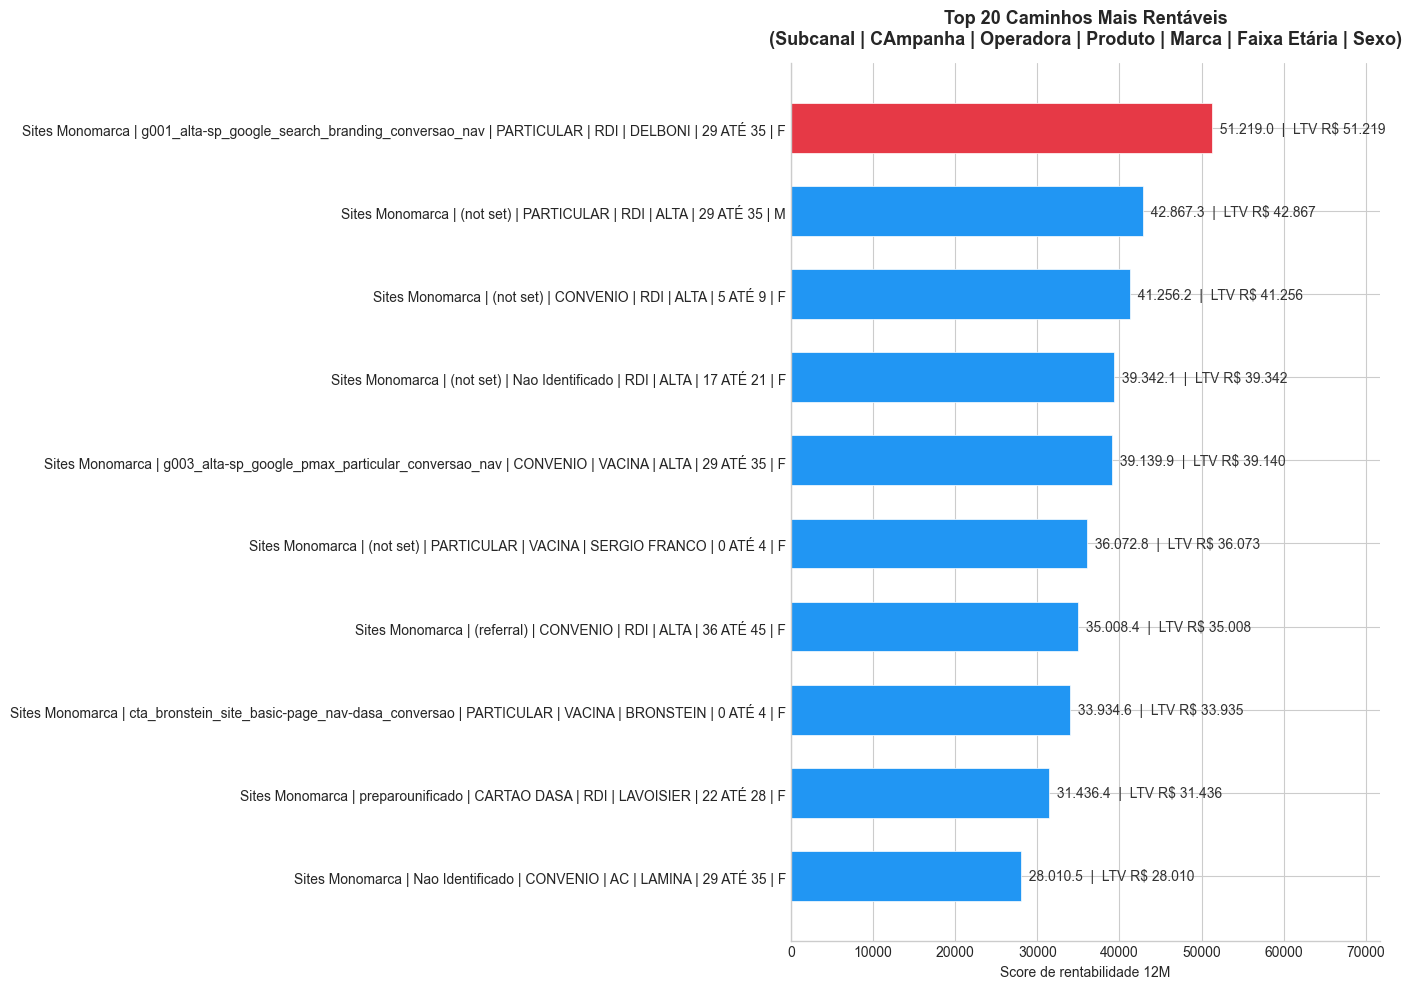

In [9]:
# Cria label legível para cada combinação
# Concatena as dimensões mais relevantes separadas por ' | '
df['label_caminho'] = (
    df['subcanal_aquisicao'].str.strip() + ' | ' +
    df['campaign_non_direct'].str.strip() + ' | ' +
    df['desc_operadora'].str.strip()     + ' | ' +
    df['grupo_exames'].str.strip()     + ' | ' +
    df['marca'].str.strip()              + ' | ' +
    df['faixa_etaria'].str.strip()       + ' | ' +
    df['sexo_paciente'].str.strip()
)

df_paid_search = df[df['subcanal_aquisicao'] == 'Sites Monomarca']  # ← filtra o subcanal
top20 = df_paid_search.nlargest(10, 'score_rentabilidade_12m')

fig, ax = plt.subplots(figsize=(14, 10))

cores = ['#E63946' if i == 0 else '#2196F3' for i in range(len(top20))]

ax.barh(
    top20['label_caminho'].iloc[::-1],
    top20['score_rentabilidade_12m'].iloc[::-1],
    color=cores[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Anota score e LTV 12M no final de cada barra
for i, (_, row) in enumerate(top20.iloc[::-1].iterrows()):
    s_fmt = f"{row['score_rentabilidade_12m']:,.1f}".replace(',', '.')
    l_fmt = f"R$ {row['ltv_medio_12m']:,.0f}".replace(',', '.')
    ax.text(
        row['score_rentabilidade_12m'],
        i,
        f"  {s_fmt}  |  LTV {l_fmt}",
        va='center',
        fontsize=10,
        color='#333333'
    )

ax.set_xlabel('Score de rentabilidade 12M', fontsize=10)
ax.set_title(
    'Top 20 Caminhos Mais Rentáveis\n(Subcanal | CAmpanha | Operadora | Produto | Marca | Faixa Etária | Sexo)',
    fontsize=13, fontweight='bold', pad=14
)
ax.tick_params(axis='y', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top20['score_rentabilidade_12m'].max() * 1.4)

plt.tight_layout()
plt.show()

In [10]:
tabela_top20_final = df_paid_search[[
    'subcanal_aquisicao',
    'ltv_medio_12m',
    'campaign_non_direct',
    'desc_operadora',
    'grupo_exames',
    'marca',
    'faixa_etaria',
    'sexo_paciente'
]].rename(columns={
    'label_caminho': 'Caminho',
    'score_rentabilidade_12m': 'Score Rentabilidade 12M',
    'ltv_medio_12m': 'LTV Médio 12M'
})

# ===============================
# 5. Exibe no terminal (VS Code)
# ===============================
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

print("\n=== TOP 20 CAMINHOS MAIS RENTÁVEIS | PAID SEARCH ===\n")
print(tabela_top20_final)


tabela_top20_final.to_csv(
    "top20_caminhos_paid_search.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_top20_final.to_excel(
    "top20_caminhos_paid_search.xlsx",
    index=False
)

print("\nArquivos gerados com sucesso:")
print("- top20_caminhos_paid_search.csv")
print("- top20_caminhos_paid_search.xlsx")




=== TOP 20 CAMINHOS MAIS RENTÁVEIS | PAID SEARCH ===

      subcanal_aquisicao  LTV Médio 12M                                                 campaign_non_direct    desc_operadora grupo_exames      marca faixa_etaria sexo_paciente
9        Sites Monomarca       51219.00                   g001_alta-sp_google_search_branding_conversao_nav        PARTICULAR          RDI    DELBONI    29 ATÉ 35             F
20       Sites Monomarca       42867.30                                                           (not set)        PARTICULAR          RDI       ALTA    29 ATÉ 35             M
24       Sites Monomarca       41256.18                                                           (not set)          CONVENIO          RDI       ALTA      5 ATÉ 9             F
30       Sites Monomarca       39342.05                                                           (not set)  Nao Identificado          RDI       ALTA    17 ATÉ 21             F
31       Sites Monomarca       39139.87                   g0

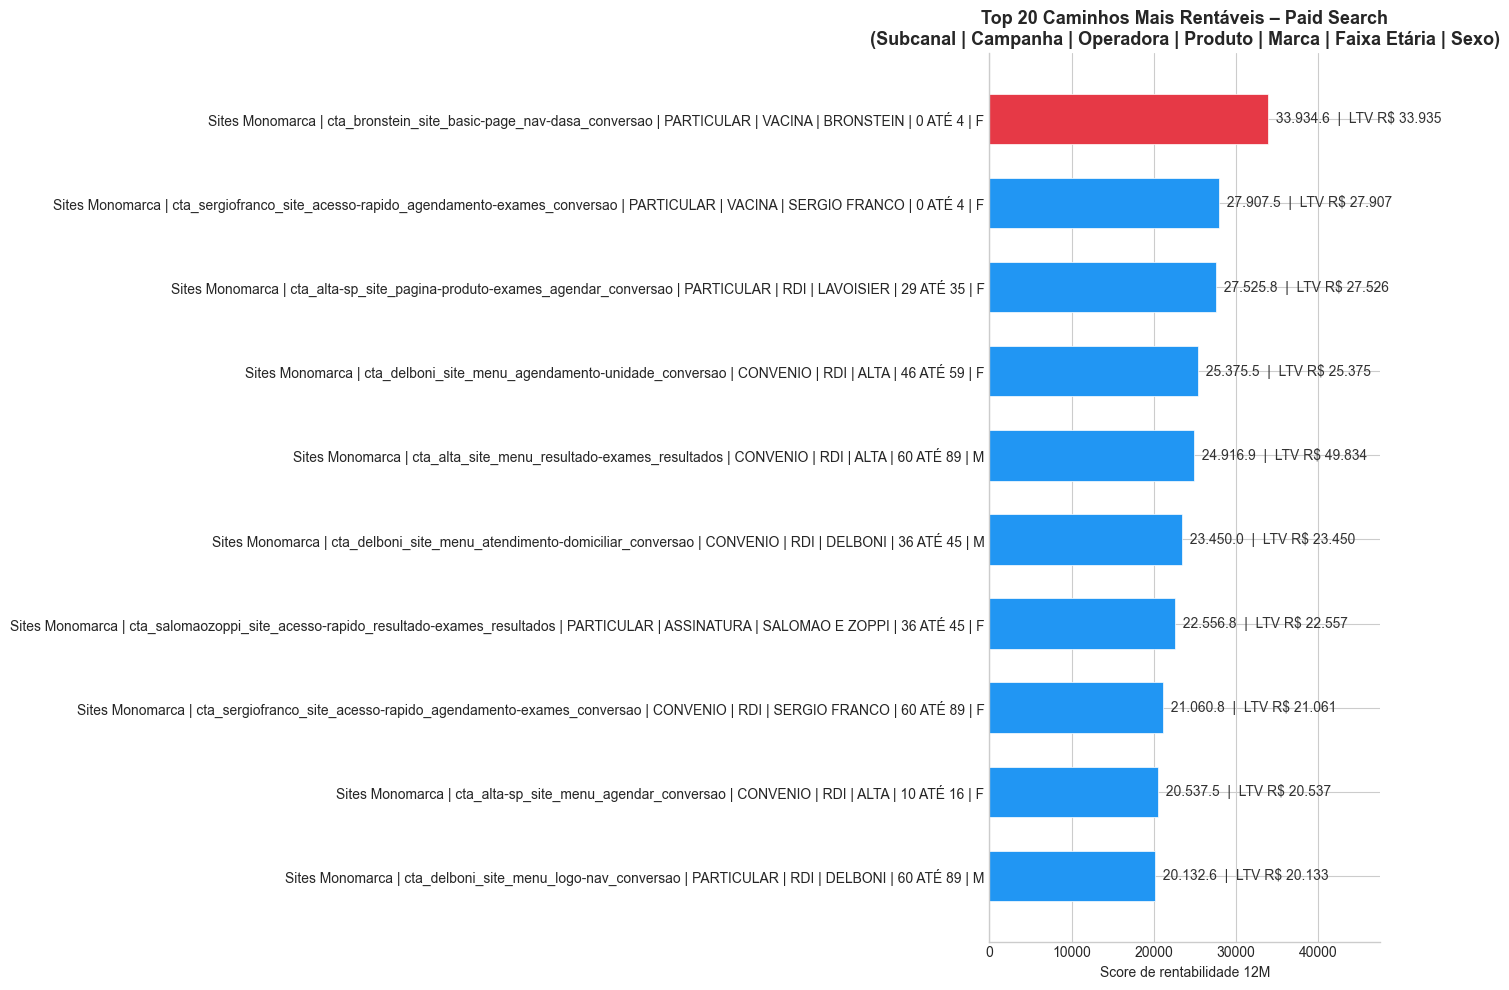

In [11]:
df_paid_search = df[df['subcanal_aquisicao'] == 'Sites Monomarca'].copy()

# Filtra apenas campanhas com prefixos válidos de Paid Search
prefixos_validos = ('cta')
df_paid_search = df_paid_search[
    df_paid_search['campaign_non_direct'].str.startswith(prefixos_validos)
]

# Cria label APÓS o filtro, usando df_paid_search
df_paid_search['label_caminho'] = (
    df_paid_search['subcanal_aquisicao'].astype(str).str.strip() + ' | ' +
    df_paid_search['campaign_non_direct'].astype(str).str.strip() + ' | ' +
    df_paid_search['desc_operadora'].astype(str).str.strip() + ' | ' +
    df_paid_search['grupo_exames'].astype(str).str.strip() + ' | ' +
    df_paid_search['marca'].astype(str).str.strip() + ' | ' +
    df_paid_search['faixa_etaria'].astype(str).str.strip() + ' | ' +
    df_paid_search['sexo_paciente'].astype(str).str.strip()
)

# Top 20 vem do df_paid_search filtrado
top20 = df_paid_search.nlargest(10, 'score_rentabilidade_12m')

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

cores = ['#E63946' if i == 0 else '#2196F3' for i in range(len(top20))]

ax.barh(
    top20['label_caminho'].iloc[::-1],
    top20['score_rentabilidade_12m'].iloc[::-1],
    color=cores[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

for i, (_, row) in enumerate(top20.iloc[::-1].iterrows()):
    s_fmt = f"{row['score_rentabilidade_12m']:,.1f}".replace(',', '.')
    l_fmt = f"R$ {row['ltv_medio_12m']:,.0f}".replace(',', '.')
    ax.text(row['score_rentabilidade_12m'], i, f"  {s_fmt}  |  LTV {l_fmt}",
            va='center', fontsize=10, color='#333333')

ax.set_xlabel('Score de rentabilidade 12M', fontsize=10)
ax.set_title(
    'Top 20 Caminhos Mais Rentáveis – Paid Search\n'
    '(Subcanal | Campanha | Operadora | Produto | Marca | Faixa Etária | Sexo)',
    fontsize=13, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top20['score_rentabilidade_12m'].max() * 1.4)

plt.tight_layout()
plt.show()
